# Fitting a simple linear regression model on housing data

In this notebook we will use data on house sales in King County, where Seattle is located, to predict house prices using simple (one feature) linear regression. We will:

- Use functions to compute important summary statistics
- Write a function to compute the Simple Linear Regression weights using the closed form solution
- Write a function to make predictions of the output given the input feature
- Turn the regression around to predict the input/feature given the output
- Compare two different models for predicting house prices

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# no need for sickit-learn

## Loading Data

In [2]:
data = pd.read_csv("../../data/kc_house_data.csv")
train_data = pd.read_csv("../../data/kc_house_train_data.csv")
test_data = pd.read_csv("../../data/kc_house_test_data.csv")

## Closed-Form Linear Regression

A generic function that accepts a column of data ‘input_feature’ and another column ‘output’ and returns the Simple Linear Regression parameters ‘intercept’ and ‘slope’.

In [3]:
# the closed-form formula: w = (Xᵀ X)⁻¹ Xᵀ y
def simple_linear_regression(input_feature, output):
    # add a column of ones for the intercept
    X = np.column_stack( ( np.ones(len(input_feature)), input_feature ) )
    y = output
    # Closed-from solution
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return(w[0], w[1])

## Using Our Function to Get the Weights

In [4]:
input_feature = train_data['sqft_living']
output = train_data['price']

In [5]:
intercept, slope = simple_linear_regression(input_feature, output)

## Making Predictions of The Output

A function that accepts a column of data ‘input_feature’, the ‘slope’, and the ‘intercept’ you learned, and returns a column of predictions ‘predicted_output’ for each entry in the input column.

In [6]:
def get_regression_predictions(input_feature, intercept, slope):
    predicted_output = intercept + slope * input_feature
    return(predicted_output)

**Quiz Question**: Using your Slope and Intercept, What is the predicted price for a house with 2650 sqft?

In [7]:
answer_1 = get_regression_predictions(2650, intercept, slope)
print ("Answer 1: ", answer_1)

Answer 1:  700074.8459475142


## Calculating the RSS

A function that accepts column of data: ‘input_feature’, and ‘output’ and the regression parameters ‘slope’ and ‘intercept’  and outputs the Residual Sum of Squares (RSS).

In [8]:
def get_rss(input_feature, output, intercept, slope):
    residuals = output - (intercept + slope * input_feature)
    RSS = np.sum( residuals ** 2 )
    return RSS

**Quiz Question**: According to this function and the slope and intercept. What is the RSS for the simple linear regression using squarefeet to predict prices on TRAINING data?

In [9]:
answer_2 = get_rss(input_feature, output, intercept, slope)
print ("Answer 2: ", f"{answer_2:.2e}")

Answer 2:  1.20e+15


## Predict The Input Given The Output

Note that although we estimated the regression slope and intercept in order to predict the output from the input, since this is a simple linear relationship with only two variables we can invert the linear function to estimate the input given the output!

A function that accept a column of data:‘output’ and the regression parameters ‘slope’ and ‘intercept’ and outputs the column of data: ‘estimated_input’.

In [10]:
def inverse_regression_predictions(output, intercept, slope):
    estimated_input = (output - intercept) / slope
    return estimated_input

**Quiz Question**: According to this function and the regression slope and intercept from, what is the estimated square-feet for a house costing $800,000?

In [11]:
answer_3 = inverse_regression_predictions(800000, intercept, slope)
print ("Answer 3: ", answer_3)

Answer 3:  3004.396245152275


## New Model: n. of bedrooms as a feature

Instead of using ‘sqft_living’ to estimate prices we could use ‘bedrooms’ (a count of the number of bedrooms in the house) to estimate prices. Using your function from calculate the Simple Linear Regression slope and intercept for estimating price based on bedrooms.

In [12]:
new_input_feature = train_data['bedrooms']

In [13]:
bedroom_intercept, bedroom_slope = simple_linear_regression(new_input_feature, output)

## Comparing The Two Models

Now that we have 2 different models compute the RSS from BOTH models on TEST data.

In [14]:
# RSS for first model: sqft_living
sqft_living_rss = get_rss(test_data['sqft_living'], test_data['price'], intercept, slope)
print ("sqft_living_rss\t: ", f"{sqft_living_rss:.2e}")
# RSS for the new model: bedrooms
bedrooms_rss = get_rss(test_data['bedrooms'], test_data['price'], bedroom_intercept, bedroom_slope)
print ("bedrooms_rss\t: ", f"{bedrooms_rss:.2e}")

sqft_living_rss	:  2.75e+14
bedrooms_rss	:  4.93e+14


**Quiz Question**: Which model (square feet or bedrooms) has lowest RSS on TEST data? Think about why this might be the case.

In [15]:
print ("Answer 4: Model 1 (Square feet)")

Answer 4: Model 1 (Square feet)


## Plotting The Two Models

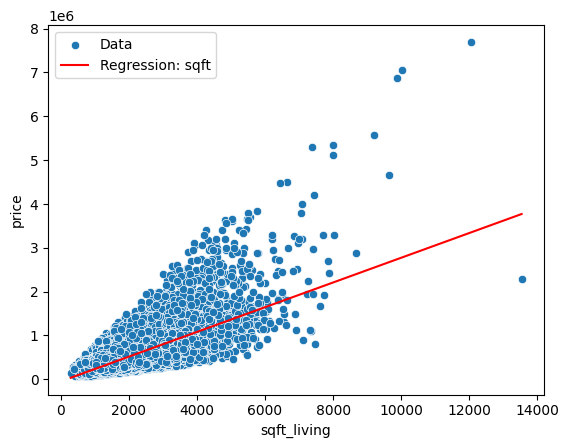

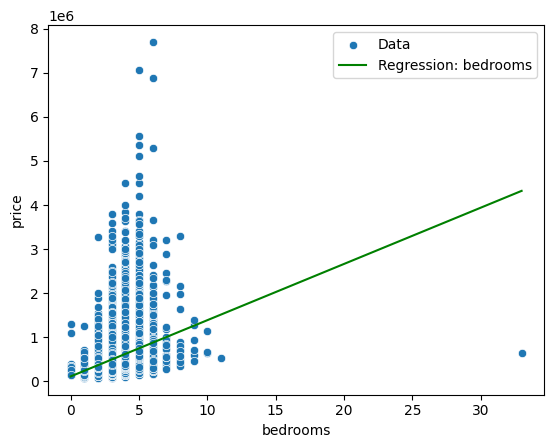

In [20]:
# --- Plot 1: sqft_living vs price ---
sqft_intercept = intercept
sqft_slope = slope
sns.scatterplot(x='sqft_living', y='price', data=data, label='Data')
# x_vals = np.linspace(data['sqft_living'].min(), data['sqft_living'].max())
x_vals = data['sqft_living']
y_vals = sqft_intercept + sqft_slope * x_vals
plt.plot(x_vals, y_vals, color='red', label='Regression: sqft')
plt.legend()
plt.show()

# --- Plot 2: bedrooms vs price ---
sns.scatterplot(x='bedrooms', y='price', data=data, label='Data')
# x_vals = np.linspace(data['bedrooms'].min(), data['bedrooms'].max())
x_vals = data['bedrooms']
y_vals = bedroom_intercept + bedroom_slope * x_vals
plt.plot(x_vals, y_vals, color='green', label='Regression: bedrooms')
plt.legend()
plt.show()

# --- Plot 3: floors vs price
sns.scatterplot(x='floors', y='price', data=data, label='Data')
x_vals = data['floors']
y_vals